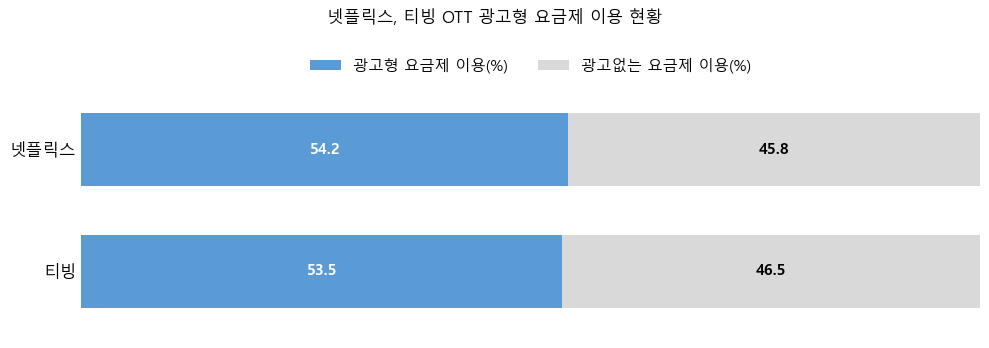

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (인코딩은 환경에 맞게 'utf-8', 'utf-8-sig', 'cp949' 중 선택)
try:
    df = pd.read_csv('광고형요금제이용여부.csv', encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv('광고형요금제이용여부.csv', encoding='cp949')

# '구분' 컬럼을 인덱스로 설정
df.set_index('구분', inplace=True)

# 🌟 '전체' 행 제외하기
if '전체' in df.index:
    df.drop('전체', inplace=True)

# 그래프에서 위에서부터 순서대로 나오도록 데이터프레임 순서 뒤집기
df = df.iloc[::-1]

# 3. 그래프 그리기 설정
# 색상 설정 (이미지와 유사한 파란색과 회색 톤)
colors = ['#5B9BD5', '#D9D9D9']

fig, ax = plt.subplots(figsize=(10, 3.5))

# 누적 가로 막대 그래프 생성
df.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.6)

# 4. 그래프 디자인 및 꾸미기
# X축 범위 설정 (0 ~ 100%)
ax.set_xlim(0, 100)

# 막대 안에 수치(텍스트) 표기
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    
    # 너비가 0보다 클 때만 텍스트 표시
    if width > 0:
        # 텍스트 위치: x좌표의 중간, y좌표의 중간
        ax.text(x + width / 2, 
                y + height / 2, 
                f'{width:.1f}', 
                ha='center', 
                va='center', 
                fontsize=11, 
                fontweight='bold',
                color='white' if x == 0 else 'black') # 파란 막대는 흰 글씨, 회색 막대는 검은 글씨

# 축 숨기기 및 라벨 제거
ax.set_ylabel('') # Y축 이름 지우기
ax.set_xticks([]) # X축 눈금 지우기

# 테두리 지우기 (위, 오른쪽, 아래, 왼쪽)
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

# Y축 눈금선 지우고 글자 크기 키우기
ax.tick_params(axis='y', length=0, labelsize=12)

# 범례 위치 조정 (그래프 위쪽 중앙)
plt.suptitle('넷플릭스, 티빙 OTT 광고형 요금제 이용 현황')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

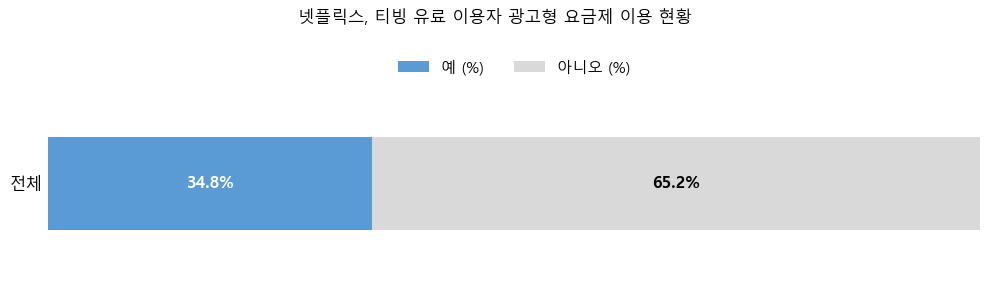

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '유료_구독형_OTT_광고형_요금제_이용_현황_20260409154811.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '전체' 데이터만 추출 및 정리
# '특성별(1)' 컬럼이 '전체'인 행만 가져옵니다.
df_total = df[df['특성별(1)'] == '전체'].copy()

# 시각화에 필요한 '예 (%)'와 '아니오 (%)' 컬럼만 추출하고, 인덱스를 '전체'로 설정
df_plot = df_total[['예 (%)', '아니오 (%)']]
df_plot.index = ['전체']

# 4. 그래프 그리기 설정
# 색상 설정 (파란색, 회색 톤)
colors = ['#5B9BD5', '#D9D9D9']

# 항목이 1개이므로 그래프 높이를 작게 설정
fig, ax = plt.subplots(figsize=(10, 3))

# 누적 가로 막대 그래프 생성
df_plot.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.4)

# 5. 그래프 디자인 및 꾸미기
# X축 범위 설정 (0 ~ 100%)
ax.set_xlim(0, 100)

# 막대 안에 수치(텍스트) 표기
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    
    # 너비가 0보다 클 때만 텍스트 표시
    if width > 0:
        # 텍스트 위치: x좌표의 중간, y좌표의 중간
        ax.text(x + width / 2, 
                y + height / 2, 
                f'{width:.1f}%',  # 가독성을 위해 % 기호 추가
                ha='center', 
                va='center', 
                fontsize=12, 
                fontweight='bold',
                color='white' if x == 0 else 'black') # 파란 막대는 흰 글씨, 회색 막대는 검은 글씨

# 축 숨기기 및 라벨 제거
ax.set_ylabel('') # Y축 이름 지우기
ax.set_xticks([]) # X축 눈금 지우기

# 테두리 지우기 (위, 오른쪽, 아래, 왼쪽)
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

# Y축 눈금선 지우고 글자 크기 키우기
ax.tick_params(axis='y', length=0, labelsize=12)

# 제목 및 범례 추가
plt.suptitle('넷플릭스, 티빙 유료 이용자 광고형 요금제 이용 현황')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

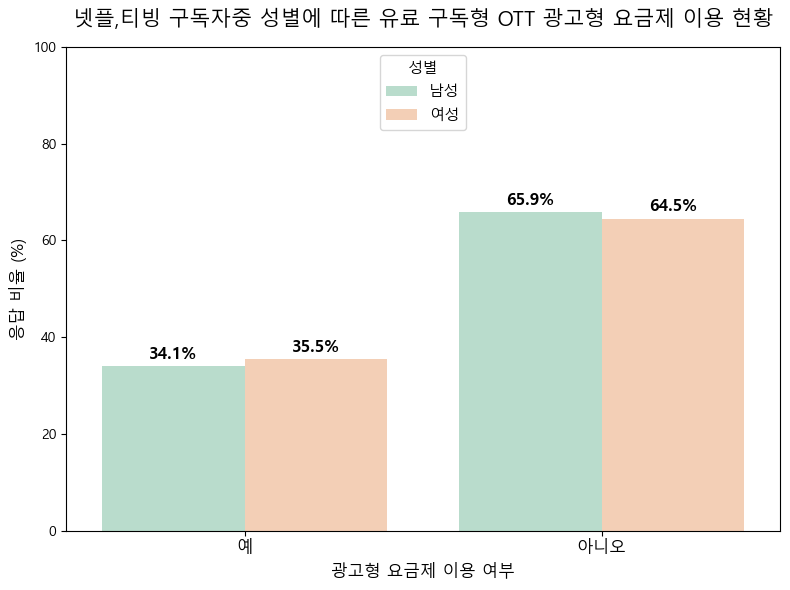

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '유료_구독형_OTT_광고형_요금제_이용_현황_20260409154811.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '성별' 데이터만 추출
# '특성별(1)' 컬럼이 '성별'인 행만 가져옵니다.
df_gender = df[df['특성별(1)'] == '성별'].copy()

# 필요한 컬럼(상세 성별, 예, 아니오)만 남기고 이름 변경
df_gender = df_gender[['특성별(2)', '예 (%)', '아니오 (%)']]
df_gender.rename(columns={'특성별(2)': '성별'}, inplace=True)

# 4. 시각화를 위한 데이터 구조 변경 (Melt)
df_melted = df_gender.melt(
    id_vars=['성별'],
    value_vars=['예 (%)', '아니오 (%)'],
    var_name='이용 여부',
    value_name='비율(%)'
)

# 컬럼명에 있는 '(%)' 텍스트를 지워 그래프 하단이 깔끔하게 보이도록 수정
df_melted['이용 여부'] = df_melted['이용 여부'].str.replace(' (%)', '', regex=False)

# 5. 그래프 그리기
plt.figure(figsize=(8, 6))

# X축: 이용 여부, 색상 구분(Hue): 성별
ax = sns.barplot(data=df_melted, x='이용 여부', y='비율(%)', hue='성별', palette='Pastel2')

# 막대 위에 수치(%) 텍스트 표시
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.text(p.get_x() + p.get_width() / 2., 
                height + 1.5, 
                f'{height}%', 
                ha='center', 
                fontsize=12,
                fontweight='bold')

# 그래프 디자인 설정
plt.title('넷플,티빙 구독자중 성별에 따른 유료 구독형 OTT 광고형 요금제 이용 현황', fontsize=15, pad=15)
plt.ylim(0, 100) # 비율이므로 y축 최대값을 100으로 고정
plt.ylabel('응답 비율 (%)', fontsize=12)
plt.xlabel('광고형 요금제 이용 여부', fontsize=12)
plt.xticks(fontsize=12)

# 범례 위치 조정
plt.legend(title='성별', title_fontsize=11, fontsize=11, loc='upper center')

plt.tight_layout()
plt.show()

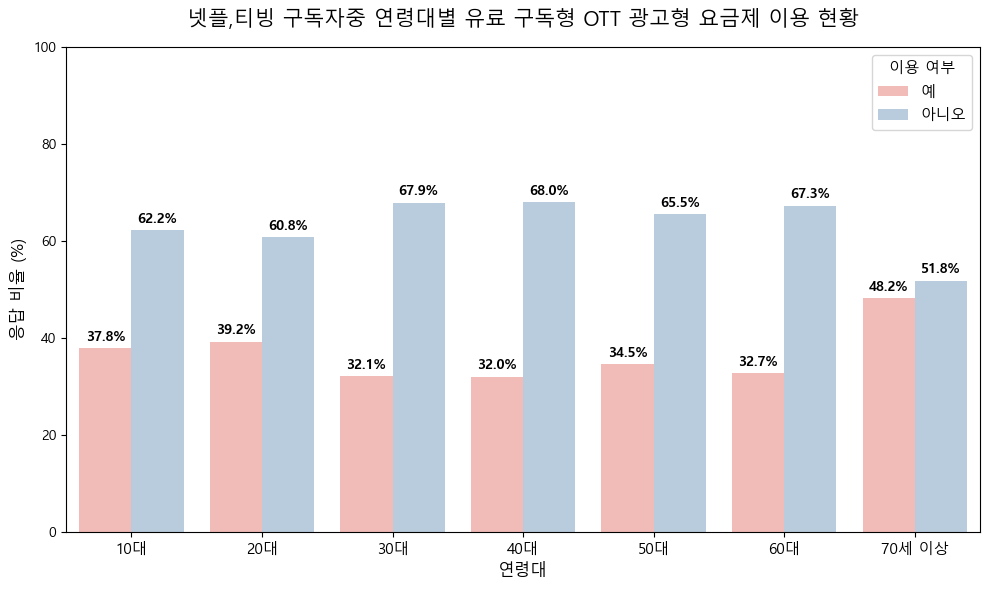

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '유료_구독형_OTT_광고형_요금제_이용_현황_20260409154811.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '연령' 데이터만 추출
# '특성별(1)' 컬럼이 '연령'인 행만 가져옵니다.
df_age = df[df['특성별(1)'] == '연령'].copy()

# 필요한 컬럼만 남기고 이름 변경
df_age = df_age[['특성별(2)', '예 (%)', '아니오 (%)']]
df_age.rename(columns={'특성별(2)': '연령대'}, inplace=True)

# 4. 시각화를 위한 데이터 구조 변경 (Melt)
df_melted = df_age.melt(
    id_vars=['연령대'],
    value_vars=['예 (%)', '아니오 (%)'],
    var_name='이용 여부',
    value_name='비율(%)'
)

# 컬럼명에 있는 '(%)' 텍스트를 지워 그래프 하단이 깔끔하게 보이도록 수정
df_melted['이용 여부'] = df_melted['이용 여부'].str.replace(' (%)', '', regex=False)

# 5. 그래프 그리기
plt.figure(figsize=(10, 6)) # 연령대 항목이 많아 가로 길이를 조금 늘렸습니다.

# X축: 연령대, 색상 구분(Hue): 이용 여부
ax = sns.barplot(data=df_melted, x='연령대', y='비율(%)', hue='이용 여부', palette='Pastel1')

# 막대 위에 수치(%) 텍스트 표시
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.text(p.get_x() + p.get_width() / 2., 
                height + 1.5, 
                f'{height}%', 
                ha='center', 
                fontsize=10,
                fontweight='bold')

# 그래프 디자인 설정
plt.title('넷플,티빙 구독자중 연령대별 유료 구독형 OTT 광고형 요금제 이용 현황', fontsize=15, pad=15)
plt.ylim(0, 100) # 비율이므로 y축 최대값을 100으로 고정
plt.ylabel('응답 비율 (%)', fontsize=12)
plt.xlabel('연령대', fontsize=12)
plt.xticks(fontsize=11)

# 범례 위치 조정
plt.legend(title='이용 여부', title_fontsize=11, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

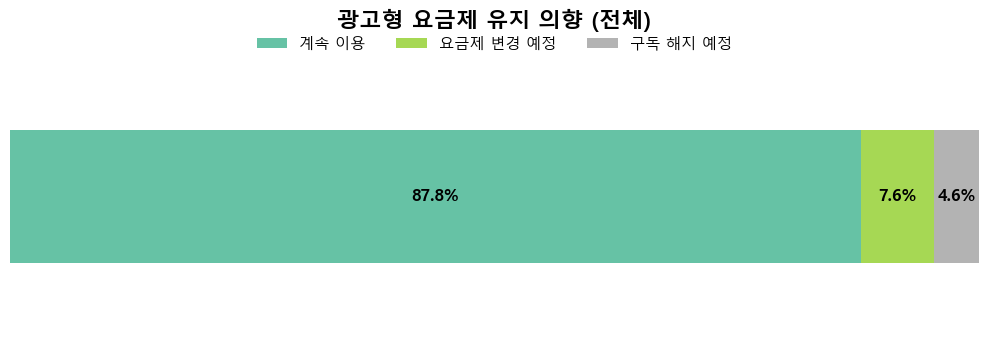

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기
file_path = 'ott_ad_plan.csv'

# 파일 구조에 맞게 인코딩 및 헤더 처리
try:
    df = pd.read_csv(file_path, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='cp949')

# '구분' 또는 '특성별(1)' 등 첫 번째 컬럼을 인덱스로 설정
index_col = '구분' if '구분' in df.columns else ('특성별(1)' if '특성별(1)' in df.columns else df.columns[0])
df.set_index(index_col, inplace=True)

# 3. '전체' 데이터만 추출
if '전체' in df.index:
    df_total = df.loc[['전체']].copy()
else:
    # 혹시 '전체'라는 단어가 포함된 다른 이름(예: '전체 응답자')일 경우를 대비
    total_idx = [idx for idx in df.index if type(idx) == str and '전체' in idx]
    if total_idx:
        df_total = df.loc[[total_idx[0]]].copy()
    else:
        df_total = df.head(1).copy() # 찾지 못하면 첫 번째 행 사용

# 시각화에 불필요한 '사례수'나 '특성별(2)' 컬럼 제거 (비율 수치만 남김)
cols_to_drop = [col for col in df_total.columns if '사례' in col or '특성' in col]
df_total = df_total.drop(columns=cols_to_drop, errors='ignore')

# 4. 그래프 그리기 설정
fig, ax = plt.subplots(figsize=(10, 3.5))

# 누적 가로 막대 그래프 생성 (구분이 잘 되는 Set2 테마 적용)
df_total.plot(kind='barh', stacked=True, colormap='Set2', ax=ax, width=0.5)

# 5. 그래프 디자인 및 꾸미기
# X축 범위를 0~100으로 설정 (비율의 합은 100%)
ax.set_xlim(0, 100)

# 막대 안에 수치(%) 텍스트 표기
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    
    # 비율이 너무 작으면 텍스트가 겹칠 수 있으므로 2% 이상일 때만 표시
    if width > 2.0:
        ax.text(x + width / 2, 
                y + height / 2, 
                f'{width:.1f}%', 
                ha='center', 
                va='center', 
                fontsize=12, 
                fontweight='bold',
                color='black')

# 축 숨기기 및 라벨 제거
ax.set_ylabel('') # Y축 이름 지우기 ('전체' 라벨)
ax.set_yticks([]) # Y축 눈금 지우기
ax.set_xticks([]) # X축 눈금 지우기

# 테두리 지우기
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

plt.title('광고형 요금제 유지 의향 (전체)', fontsize=16, fontweight='bold', pad=25)

# 범례 위치 조정 (항목 개수에 맞춰 가로로 나열되도록 ncol 자동 설정)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=len(df_total.columns), frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

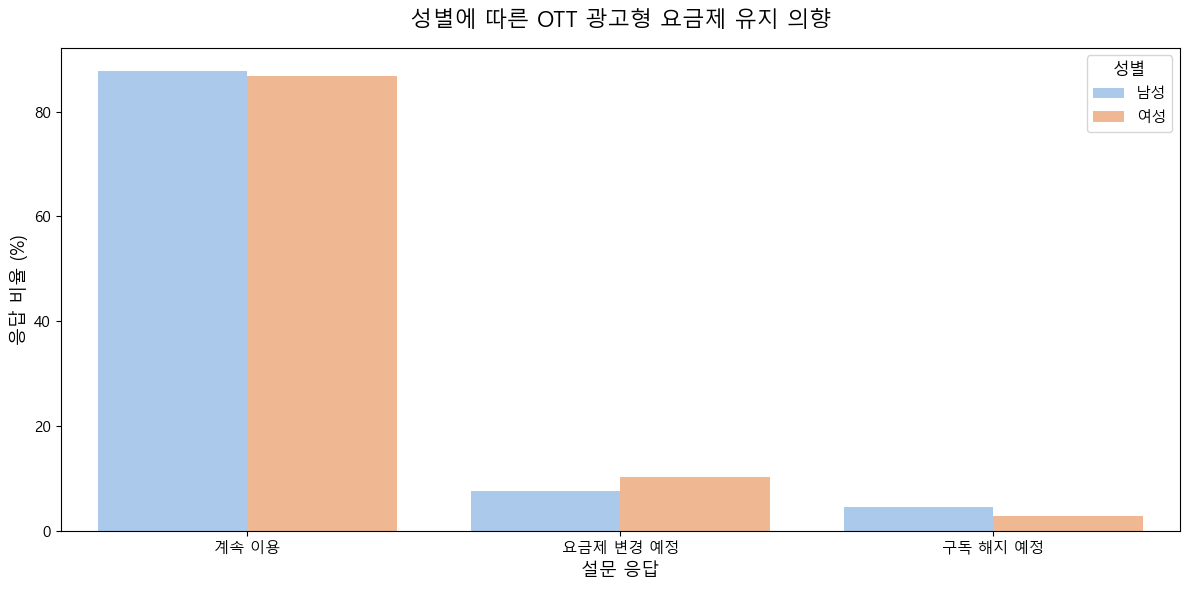

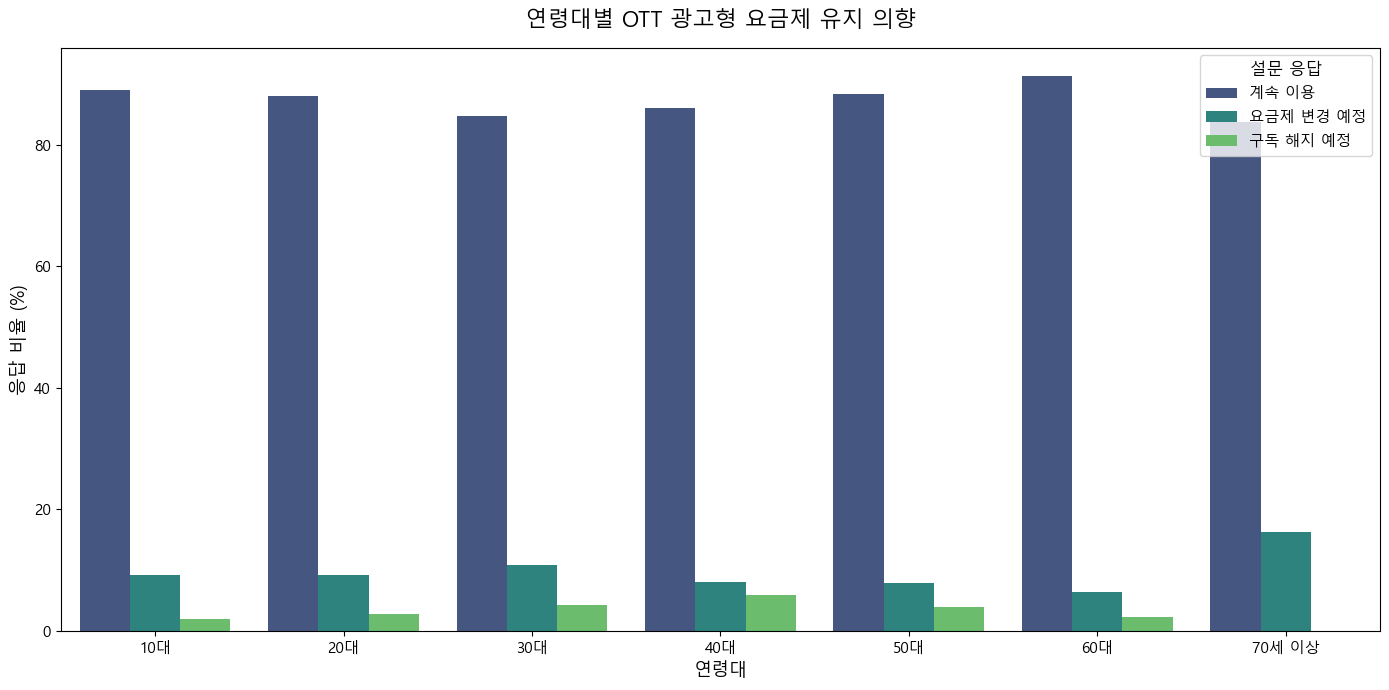

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정 (시스템 환경에 맞게 주석을 해제하여 사용하세요)
# Windows 사용자 기본: Malgun Gothic
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic' # Mac 사용자
# plt.rcParams['font.family'] = 'NanumGothic' # Ubuntu/Server 사용자
# Colab 등의 경우 별도 폰트 설치 및 설정이 필요할 수 있습니다.
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 2. 데이터 불러오기
# (파일 이름이 다를 경우 알맞게 수정해주세요. 한글 인코딩을 위해 cp949를 사용합니다.)
df = pd.read_csv('ott_ad_plan.csv', encoding='utf-8')

# 3. '성별' 데이터만 추출하여 시각화
df_gender = df[df['구분'] == '성별'].copy()

# 시각화를 위한 데이터 재구조화 (Melt)
# 세 개의 비율(%) 컬럼을 하나의 '설문 응답' 컬럼과 '비율(%)' 컬럼으로 길게 변환합니다.
df_gender_melted = df_gender.melt(
    id_vars=['상세'], 
    value_vars=['계속 이용', '요금제 변경 예정', '구독 해지 예정'],
    var_name='설문 응답',
    value_name='비율(%)'
)

# 그래프 그리기 (성별 비교)
plt.figure(figsize=(12, 6))
# x축에는 설문 응답을, y축에는 비율을 표시하며, 남성/여성을 색상으로 구분합니다.
sns.barplot(data=df_gender_melted, x='설문 응답', y='비율(%)', hue='상세', palette='pastel')

# 제목 및 축 이름 설정
plt.title('성별에 따른 OTT 광고형 요금제 유지 의향', fontsize=16, pad=15)
plt.xlabel('설문 응답', fontsize=13)
plt.ylabel('응답 비율 (%)', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title='성별', title_fontsize=12, fontsize=11)
plt.tight_layout()
# plt.savefig('gender_plot.png') # 이미지로 저장하려면 주석 해제
plt.show()

# 4. '연령' 데이터만 추출하여 시각화 (동일한 데이터프레임 사용)
df_age = df[df['구분'] == '연령'].copy()

# 시각화를 위한 데이터 재구조화 (Melt)
df_age_melted = df_age.melt(
    id_vars=['상세'], 
    value_vars=['계속 이용', '요금제 변경 예정', '구독 해지 예정'],
    var_name='설문 응답',
    value_name='비율(%)'
)

# 그래프 그리기 (연령대별 비교)
# 연령대는 7개 항목이 들어가므로 그래프를 조금 더 넓게 설정합니다.
plt.figure(figsize=(14, 7))
# x축을 연령대, hue를 응답 종류로 설정하여 각 연령대별 응답 비율을 한눈에 비교합니다. (데이터 가독성 높임)
sns.barplot(data=df_age_melted, x='상세', y='비율(%)', hue='설문 응답', palette='viridis')

# 제목 및 축 이름 설정
plt.title('연령대별 OTT 광고형 요금제 유지 의향', fontsize=16, pad=15)
plt.xlabel('연령대', fontsize=13)
plt.ylabel('응답 비율 (%)', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title='설문 응답', title_fontsize=12, fontsize=11)
plt.tight_layout()
# plt.savefig('age_plot.png') # 이미지로 저장하려면 주석 해제
plt.show()

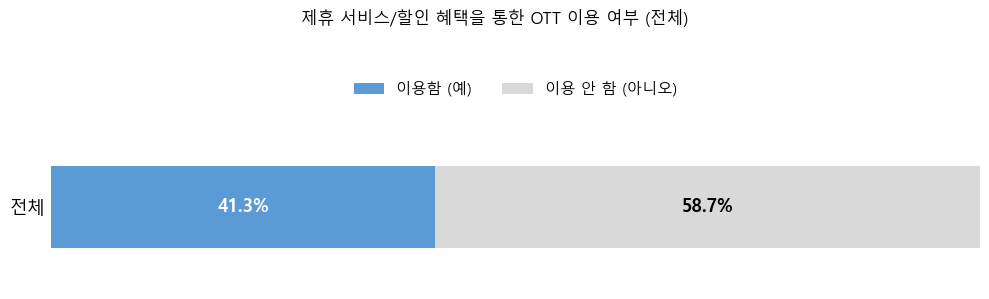

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경 (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '제휴_서비스_할인_혜택을_통한_OTT_이용_여부_20260409140724.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '전체' 데이터 추출 및 처리 로직 보완
# '특성별(1)'이 '전체'이거나 '특성별(2)'가 '소계'인 행을 먼저 찾아봅니다.
df_total_row = df[(df['특성별(1)'] == '전체') | (df['특성별(2)'] == '소계')]

if not df_total_row.empty:
    # '전체' 혹은 '소계' 행이 존재하는 경우 해당 행 사용
    df_plot = df_total_row[['예 (%)', '아니오 (%)']].head(1).copy()
else:
    # '전체' 행이 없는 경우, '성별' 데이터를 기반으로 가중 평균을 계산하여 전체 수치를 도출합니다.
    df_gender = df[df['특성별(1)'] == '성별'].copy()
    
    # 사례수(명)를 기준으로 가중 평균 계산
    total_samples = df_gender['사례수 (명)'].sum()
    yes_rate = (df_gender['예 (%)'] * df_gender['사례수 (명)']).sum() / total_samples
    no_rate = (df_gender['아니오 (%)'] * df_gender['사례수 (명)']).sum() / total_samples
    
    df_plot = pd.DataFrame({'예 (%)': [yes_rate], '아니오 (%)': [no_rate]})

df_plot.index = ['전체']

# 4. 그래프 그리기 설정
colors = ['#5B9BD5', '#D9D9D9'] # 이용함(파랑), 이용안함(회색)
fig, ax = plt.subplots(figsize=(10, 3))

# 누적 가로 막대 그래프 생성
df_plot.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.5)

# 5. 그래프 디자인 및 꾸미기
ax.set_xlim(0, 100)

# 막대 안에 수치(%) 표기
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    
    if width > 0:
        ax.text(x + width / 2, 
                y + height / 2, 
                f'{width:.1f}%', 
                ha='center', 
                va='center', 
                fontsize=13, 
                fontweight='bold',
                color='white' if x == 0 else 'black')

# 축 및 테두리 정리
ax.set_ylabel('')
ax.set_xticks([])
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis='y', length=0, labelsize=13)

# 제목 및 범례
plt.suptitle('제휴 서비스/할인 혜택을 통한 OTT 이용 여부 (전체)')
ax.legend(['이용함 (예)', '이용 안 함 (아니오)'], 
          loc='upper center', bbox_to_anchor=(0.5, 1.35), 
          ncol=2, frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

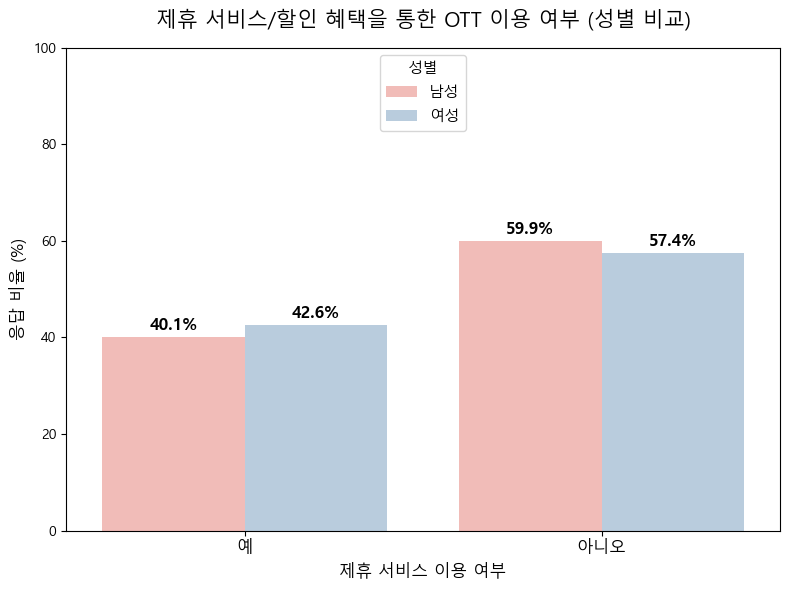

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '제휴_서비스_할인_혜택을_통한_OTT_이용_여부_20260409140724.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '성별' 데이터만 추출
df_gender = df[df['특성별(1)'] == '성별'].copy()

# 필요한 컬럼만 남기고 이름 변경
df_gender = df_gender[['특성별(2)', '예 (%)', '아니오 (%)']]
df_gender.rename(columns={'특성별(2)': '성별'}, inplace=True)

# 4. 시각화를 위한 데이터 구조 변경 (Melt)
df_melted = df_gender.melt(
    id_vars=['성별'],
    value_vars=['예 (%)', '아니오 (%)'],
    var_name='이용 여부',
    value_name='비율(%)'
)

# 컬럼명에 있는 '(%)' 텍스트를 지워 그래프 하단이 깔끔하게 보이도록 수정
df_melted['이용 여부'] = df_melted['이용 여부'].str.replace(' (%)', '', regex=False)

# 5. 그래프 그리기
plt.figure(figsize=(8, 6))

# X축: 이용 여부, 색상 구분(Hue): 성별
ax = sns.barplot(data=df_melted, x='이용 여부', y='비율(%)', hue='성별', palette='Pastel1')

# 막대 위에 수치(%) 텍스트 표시
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.text(p.get_x() + p.get_width() / 2., 
                height + 1.5, 
                f'{height}%', 
                ha='center', 
                fontsize=12,
                fontweight='bold')

# 그래프 디자인 설정
plt.title('제휴 서비스/할인 혜택을 통한 OTT 이용 여부 (성별 비교)', fontsize=15, pad=15)
plt.ylim(0, 100) # 비율이므로 y축 최대값을 100으로 고정
plt.ylabel('응답 비율 (%)', fontsize=12)
plt.xlabel('제휴 서비스 이용 여부', fontsize=12)
plt.xticks(fontsize=12)

# 범례 위치 조정
plt.legend(title='성별', title_fontsize=11, fontsize=11, loc='upper center')

plt.tight_layout()
plt.show()

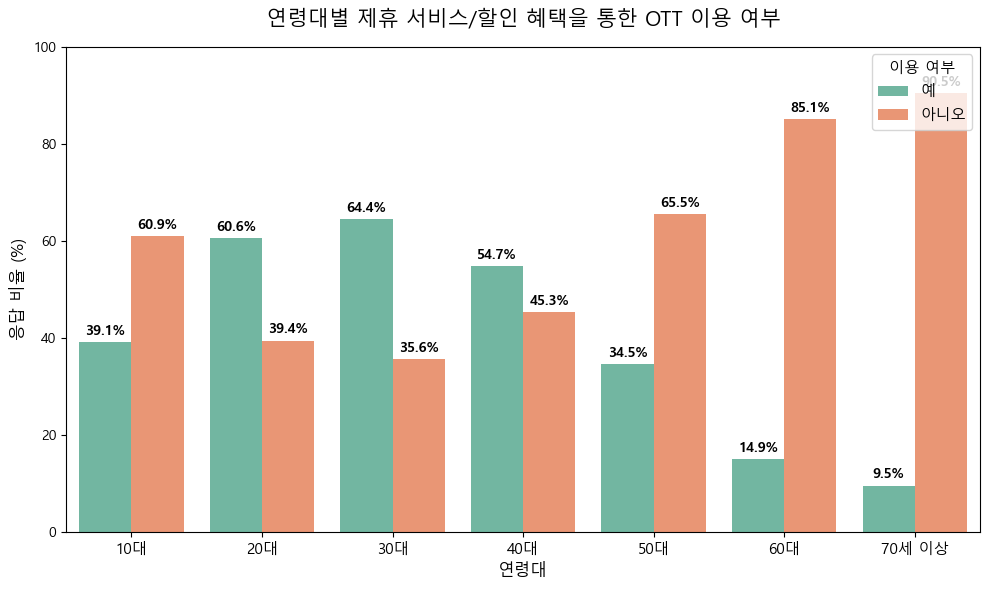

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (두 번째 줄을 헤더로 인식)
file_path = '제휴_서비스_할인_혜택을_통한_OTT_이용_여부_20260409140724.csv'

try:
    df = pd.read_csv(file_path, header=1, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, header=1, encoding='cp949')

# 3. '연령' 데이터만 추출
df_age = df[df['특성별(1)'] == '연령'].copy()

# 필요한 컬럼만 남기고 이름 변경
df_age = df_age[['특성별(2)', '예 (%)', '아니오 (%)']]
df_age.rename(columns={'특성별(2)': '연령대'}, inplace=True)

# 4. 시각화를 위한 데이터 구조 변경 (Melt)
df_melted = df_age.melt(
    id_vars=['연령대'],
    value_vars=['예 (%)', '아니오 (%)'],
    var_name='이용 여부',
    value_name='비율(%)'
)

# 컬럼명에 있는 '(%)' 텍스트를 지워 그래프 하단이 깔끔하게 보이도록 수정
df_melted['이용 여부'] = df_melted['이용 여부'].str.replace(' (%)', '', regex=False)

# 5. 그래프 그리기
plt.figure(figsize=(10, 6)) # 연령대 항목이 많아 가로 길이를 조금 늘렸습니다.

# X축: 연령대, 색상 구분(Hue): 이용 여부
ax = sns.barplot(data=df_melted, x='연령대', y='비율(%)', hue='이용 여부', palette='Set2')

# 막대 위에 수치(%) 텍스트 표시
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.text(p.get_x() + p.get_width() / 2., 
                height + 1.5, 
                f'{height}%', 
                ha='center', 
                fontsize=10,
                fontweight='bold')

# 그래프 디자인 설정
plt.title('연령대별 제휴 서비스/할인 혜택을 통한 OTT 이용 여부', fontsize=15, pad=15)
plt.ylim(0, 100) # 비율이므로 y축 최대값을 100으로 고정
plt.ylabel('응답 비율 (%)', fontsize=12)
plt.xlabel('연령대', fontsize=12)
plt.xticks(fontsize=11)

# 범례 위치 조정
plt.legend(title='이용 여부', title_fontsize=11, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()